## **Name: Chirag Chaudhari**
## **Roll no: 24102A2003**
## **Branch: CMPN-A**
## **Experiment - 1**

Import and Inspect Dataset

In [4]:
# Import Dataset
file <- "PRSA_Data_Tiantan.csv"

air_quality <- tryCatch({
  read.csv(file)
}, error = function(e){
  cat("Error:", e$message)
})

# Display Information
head(air_quality)
str(air_quality)
dim(air_quality)

# Check Missing Values
any(is.na(air_quality))
sum(is.na(air_quality))

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,1,2013,3,1,0,6,6,4,8,300,81,-0.5,1024.5,-21.4,0,NNW,5.7,Tiantan
2,2,2013,3,1,1,6,29,5,9,300,80,-0.7,1025.1,-22.1,0,NW,3.9,Tiantan
3,3,2013,3,1,2,6,6,4,12,300,75,-1.2,1025.3,-24.6,0,NNW,5.3,Tiantan
4,4,2013,3,1,3,6,6,4,12,300,74,-1.4,1026.2,-25.5,0,N,4.9,Tiantan
5,5,2013,3,1,4,5,5,7,15,400,70,-1.9,1027.1,-24.5,0,NNW,3.2,Tiantan
6,6,2013,3,1,5,10,10,12,15,400,70,-2.4,1027.5,-21.3,0,NW,2.4,Tiantan


'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hour   : int  0 1 2 3 4 5 6 7 8 9 ...
 $ PM2.5  : num  6 6 6 6 5 10 8 7 3 8 ...
 $ PM10   : num  6 29 6 6 5 10 19 7 6 2 ...
 $ SO2    : num  4 5 4 4 7 12 12 12 14 11 ...
 $ NO2    : num  8 9 12 12 15 15 14 19 29 22 ...
 $ CO     : int  300 300 300 300 400 400 400 400 500 500 ...
 $ O3     : num  81 80 75 74 70 70 72 67 56 65 ...
 $ TEMP   : num  -0.5 -0.7 -1.2 -1.4 -1.9 -2.4 -2.5 -1.4 -0.3 0.4 ...
 $ PRES   : num  1024 1025 1025 1026 1027 ...
 $ DEWP   : num  -21.4 -22.1 -24.6 -25.5 -24.5 -21.3 -20.4 -20.4 -21.2 -23.3 ...
 $ RAIN   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ wd     : chr  "NNW" "NW" "NNW" "N" ...
 $ WSPM   : num  5.7 3.9 5.3 4.9 3.2 2.4 2.2 3 4.6 5.5 ...
 $ station: chr  "Tiantan" "Tiantan" "Tiantan" "Tiantan" ...


[1] 35064    18

[1] TRUE

[1] 5277

Check NA, NULL and NaN

In [5]:
# Examples
x <- c(10,20,NA,40)
y <- NULL
z <- 0/0

# Check
is.na(x)
is.null(y)
is.nan(z)

# Display
x
y
z

[1] FALSE FALSE  TRUE FALSE

[1] TRUE

[1] TRUE

[1] 10 20 NA 40

NULL

[1] NaN

Missing Summary Function

In [6]:
missing_summary <- function(data){

vars <- c("PM2.5","PM10","SO2","NO2","TEMP","WSPM","wd")

for(v in vars){

missing <- sum(is.na(data[[v]]))
percent <- (missing/nrow(data))*100

cat(v," Missing =",missing,
    " Percentage =",round(percent,2),"%\n")

if(percent>20)
warning(v," has more than 20% missing values")

}
}

missing_summary(air_quality)

PM2.5  Missing = 677  Percentage = 1.93 %
PM10  Missing = 597  Percentage = 1.7 %
SO2  Missing = 1118  Percentage = 3.19 %
NO2  Missing = 744  Percentage = 2.12 %
TEMP  Missing = 20  Percentage = 0.06 %
WSPM  Missing = 14  Percentage = 0.04 %
wd  Missing = 78  Percentage = 0.22 %


Identify Invalid Numerical Results

In [7]:
# Create pollution_ratio
air_quality$pollution_ratio <- air_quality$PM2.5 / air_quality$PM10

# Count invalid values
sum(is.na(air_quality$pollution_ratio))
sum(is.nan(air_quality$pollution_ratio))
sum(is.infinite(air_quality$pollution_ratio))

# Replace NaN and Inf with NA
air_quality$pollution_ratio[
  is.nan(air_quality$pollution_ratio) |
  is.infinite(air_quality$pollution_ratio)
] <- NA

[1] 693

[1] 0

[1] 0

Replace Missing Numerical Values Using Loop

In [8]:
numeric_variables <- c("PM2.5","PM10","SO2","NO2","TEMP","WSPM")

before_missing <- c()

for(v in numeric_variables){

  before <- sum(is.na(air_quality[[v]]))
  before_missing[v] <- before

  med <- median(air_quality[[v]], na.rm = TRUE)

  air_quality[[v]][is.na(air_quality[[v]])] <- med

  after <- sum(is.na(air_quality[[v]]))

  cat(v,
      " Before:", before,
      " Median:", med,
      " After:", after,"\n")
}

PM2.5  Before: 677  Median: 59  After: 0 
PM10  Before: 597  Median: 85  After: 0 
SO2  Before: 1118  Median: 7  After: 0 
NO2  Before: 744  Median: 47  After: 0 
TEMP  Before: 20  Median: 14.6  After: 0 
WSPM  Before: 14  Median: 1.5  After: 0 


Replace Missing Categorical Values

In [9]:
calculate_mode <- function(x){
  names(sort(table(x), decreasing=TRUE))[1]
}

before_wd <- sum(is.na(air_quality$wd))

mode_wd <- calculate_mode(na.omit(air_quality$wd))

air_quality$wd[is.na(air_quality$wd)] <- mode_wd

after_wd <- sum(is.na(air_quality$wd))

cat("Mode:", mode_wd,"\n")
cat("Before:", before_wd,"\n")
cat("After:", after_wd,"\n")

Mode: ENE 
Before: 78 
After: 0 


Error Handling Function

In [10]:
clean_variable <- function(data,var){

tryCatch({

if(!(var %in% names(data)))
stop("Variable not found")

if(!is.numeric(data[[var]]))
stop("Not Numeric")

if(all(is.na(data[[var]])))
stop("All values are NA")

m <- median(data[[var]],na.rm=TRUE)

data[[var]][is.na(data[[var]])] <- m

return(data[[var]])

},error=function(e){
cat("Error:",e$message,"\n")
})
}

clean_variable(air_quality,"PM2.5")

[1]   6.0   6.0   6.0   6.0   5.0  10.0   8.0   7.0   3.0   8.0   9.0   9.0
   [13]   9.0  10.0  10.0   3.0   8.0  10.0  11.0  12.0  12.0  12.0  12.0  15.0
   [25]  16.0   3.0   4.0   9.0   3.0   6.0   5.0   3.0  12.0  13.0  18.0  16.0
   [37]  26.0  27.0  35.0  35.0  48.0  56.0  49.0  64.0  63.0  73.0  79.0  98.0
   [49]  84.0  85.0 110.0 112.0 113.0  84.0  77.0  73.0  74.0  90.0  96.0  96.0
   [61] 105.0 114.0  92.0 102.0  98.0  77.0  84.0 128.0 141.0 142.0 107.0  69.0
   [73]  44.0  52.0  11.0  13.0   6.0   7.0   9.0  10.0  14.0  21.0  20.0  13.0
   [85]  16.0  14.0  16.0   5.0  15.0  17.0  22.0  25.0  31.0  44.0  53.0  58.0
   [97]  71.0  76.0  98.0 100.0 108.0 130.0 125.0 120.0 103.0 114.0 127.0 142.0
  [109] 151.0 161.0 182.0 198.0 168.0 150.0 147.0 162.0 198.0 199.0 184.0 186.0
  [121] 187.0 198.0 199.0 173.0 157.0 151.0 184.0 160.0 197.0 158.0 145.0 175.0
  [133] 186.0 199.0 216.0 195.0 229.0 235.0 234.0 239.0 230.0 196.0 202.0 204.0
  [145] 209.0 219.0 259.0 222.0 215.0 211.0 214.0 209.0 243.0 244.0 296.0 366.0
  [157] 390.0 386.0 285.0 317.0 240.0 161.0 206.0 183.0 178.0 236.0 301.0 390.0
  [169] 437.0 424.0 456.0 382.0 377.0 335.0  59.0  59.0   3.0   3.0  59.0 266.0
  [181] 167.0 146.0 207.0 272.0 162.0 104.0  84.0  86.0  61.0  57.0  90.0  57.0
  [193]  55.0  62.0  76.0  82.0  80.0  80.0  84.0 113.0 119.0 117.0 141.0 104.0
  [205]  87.0  67.0  46.0  25.0  16.0  18.0  17.0  16.0  18.0  12.0  10.0   3.0
  [217]   9.0   6.0  10.0  12.0  19.0  18.0  19.0  26.0  27.0  24.0  27.0  31.0
  [229]  30.0  33.0  34.0  38.0  32.0  45.0  54.0  67.0  78.0  87.0  95.0  98.0
  [241]  86.0  96.0 102.0 104.0 104.0 108.0 100.0  88.0 103.0 113.0 121.0 142.0
  [253] 148.0 136.0 122.0 110.0 116.0 141.0 142.0 152.0 166.0 183.0 140.0 106.0
  [265] 103.0 120.0 132.0 108.0 122.0 129.0 140.0 113.0 122.0  97.0 135.0 136.0
  [277] 122.0 150.0 146.0 128.0 134.0 118.0 139.0 114.0 141.0 131.0 142.0 125.0
  [289]  39.0  10.0   3.0   7.0  10.0   3.0   8.0   9.0  12.0  12.0   3.0   3.0
  [301]  19.0   6.0   3.0   3.0  18.0  20.0  14.0  33.0  35.0  45.0  40.0  51.0
  [313]  68.0  69.0  57.0  54.0  58.0  61.0  62.0  63.0  75.0  81.0  91.0 110.0
  [325]  95.0  89.0  86.0  77.0  97.0  86.0  92.0 109.0  93.0 102.0 112.0 126.0
  [337] 134.0 134.0 160.0 175.0 159.0 183.0 159.0 152.0 166.0 172.0 172.0 153.0
  [349] 208.0   3.0 197.0 274.0 249.0 233.0 236.0 246.0 249.0 245.0 260.0 234.0
  [361] 294.0 339.0 320.0 285.0 282.0 313.0 305.0 305.0 311.0 280.0 275.0 250.0
  [373] 187.0 218.0 208.0 175.0 220.0 166.0 204.0 167.0 210.0 241.0 206.0 186.0
  [385] 146.0 165.0 214.0 214.0 214.0 223.0 212.0 201.0 199.0 174.0 215.0 249.0
  [397] 279.0 310.0 407.0 363.0 358.0 357.0 368.0 417.0 424.0 426.0 394.0 419.0
  [409] 498.0 480.0 370.0  41.0  22.0  19.0  17.0  13.0   3.0   9.0  15.0   3.0
  [421]   3.0   3.0   7.0  17.0  17.0  12.0  38.0  71.0  41.0  19.0  16.0  16.0
  [433]  14.0  31.0  12.0  22.0   9.0  10.0  23.0   6.0  33.0  38.0  52.0  53.0
  [445]  43.0  46.0  55.0  70.0  50.0  53.0  47.0  56.0  72.0  78.0  86.0  86.0
  [457]  51.0  50.0  44.0  49.0  50.0  50.0  33.0  30.0  32.0  59.0  77.0  73.0
  [469]  78.0  63.0  44.0  47.0  34.0  59.0  47.0  78.0  86.0  72.0  86.0  88.0
  [481] 107.0  99.0  89.0  82.0  84.0  84.0  85.0  76.0  96.0  76.0 123.0 131.0
  [493] 143.0 171.0 167.0 153.0 181.0 160.0 191.0 198.0 200.0 179.0 194.0 164.0
  [505] 191.0 156.0 101.0  71.0 141.0  44.0  13.0  16.0  12.0 126.0 122.0 119.0
  [517]  52.0  54.0  71.0  60.0  56.0  66.0  61.0  60.0  66.0  58.0  61.0  63.0
  [529]  63.0  56.0  50.0  44.0  48.0  48.0  34.0  37.0  58.0  53.0  79.0  87.0
  [541]  86.0  89.0  93.0 101.0  87.0  64.0  20.0  10.0   3.0   8.0   6.0   8.0
  [553]   6.0   3.0   8.0   5.0   6.0   7.0   3.0   6.0  12.0  12.0   9.0   8.0
  [565]  18.0  10.0   7.0   3.0   7.0  10.0  20.0  26.0  45.0  54.0  47.0  50.0
  [577]  51.0  63.0  76.0  75.0  75.0  65.0  68.0  73.0  89.0 102.0 105.0 118.0
  [589] 113.0 119.0 123.0 108.0  95.0 104.0 104.0 120.0 134.0 110.0  84.0  65.0
  [6

Comparison Table

In [11]:
after_missing <- sapply(c("PM2.5","PM10","SO2","NO2","TEMP","WSPM"),
                        function(x) sum(is.na(air_quality[[x]])))

comparison <- data.frame(
  Variable=names(before_missing),
  Missing_Before=before_missing,
  Missing_After=after_missing,
  Values_Replaced=before_missing-after_missing
)

comparison

,Variable,Missing_Before,Missing_After,Values_Replaced
,<chr>,<int>,<int>,<int>
PM2.5,PM2.5,677,0,677
PM10,PM10,597,0,597
SO2,SO2,1118,0,1118
NO2,NO2,744,0,744
TEMP,TEMP,20,0,20
WSPM,WSPM,14,0,14


Bar Chart

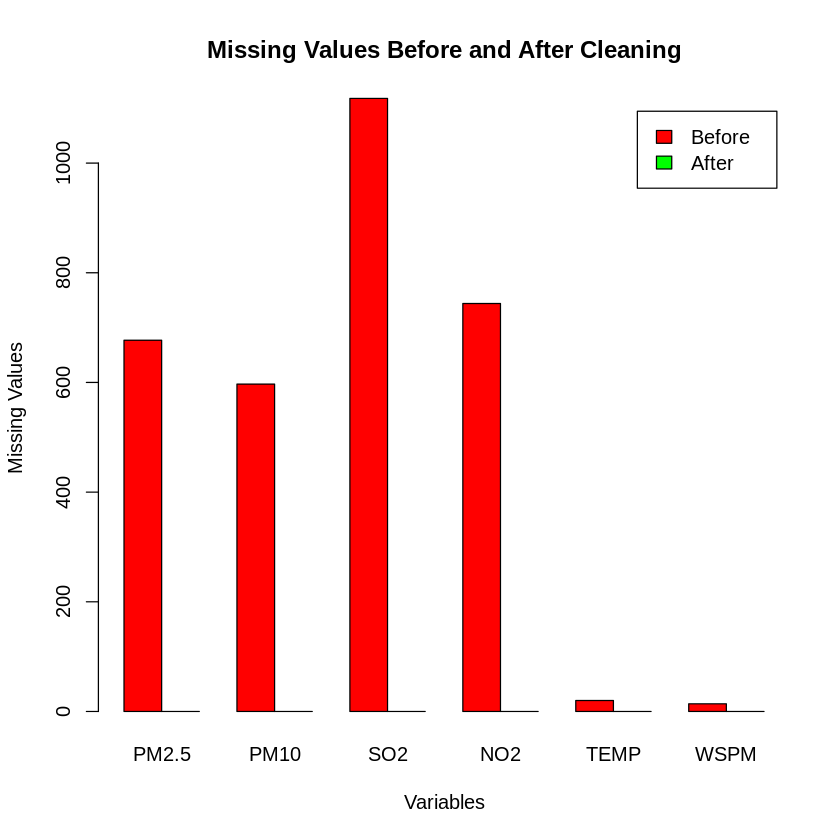

In [12]:
barplot(
rbind(before_missing,after_missing),
beside=TRUE,
col=c("red","green"),
legend=c("Before","After"),
main="Missing Values Before and After Cleaning",
xlab="Variables",
ylab="Missing Values"
)

Export Cleaned Dataset

In [13]:
write.csv(
air_quality,
"cleaned_air_quality_data.csv",
row.names=FALSE
)

cat("Dataset Exported Successfully")

Dataset Exported Successfully

The air quality dataset was successfully cleaned by identifying and handling missing and invalid values. Missing numerical values in PM2.5, PM10, SO2, NO2, TEMP, and WSPM were replaced using the median of each variable, while missing values in the categorical variable wd were replaced using the mode. Invalid values such as NaN and infinite values in the pollution_ratio variable were converted to NA before cleaning. A comparison of missing values before and after cleaning confirmed that all selected variables were successfully processed. The cleaned dataset is now consistent and suitable for further statistical analysis, visualization, and machine learning tasks.